In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from rollover import * 
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

Analyzing different mode collecting methods

We analyze whether collecting two quadratures and one quadrature assissting in performance.
- When no mask is applied
- When masked is applied

In [53]:
N=15
rep=1
name = 'SP500'

In [55]:
df = pd.read_csv(f"{name}_Features_2014_2024_rep{rep}_tau{N}.csv")
X_p = extract_delayed_p_or_q_single_column(df,column_name="PQ-15",N=N,repeat_steps=rep)
X_p.shape

(2516, 15)

In [57]:
X_pq = extract_delayed_single_column(df,column_name="PQ-15",N=N*2,repeat_steps=rep)
X_pq.shape

(2516, 30)

In [59]:
column_names = [f"PQ-{i}" for i in range(N-1, 0, -1)] + ["PQ0"]
X_p_row = extract_p_row(df,column_names=column_names,repeat_steps=rep,keep_last=True)
X_p_row.shape

(2516, 15)

In [63]:
start = 2014
end = 2024
name = '^GSPC'
results = rollover(start, end, name, X_pq, tau=1, Nfading=10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04086036 0.12795231 0.12448866 0.08743402 0.14566189 0.36240463
 0.29191463 0.10673517]
Mean NRMSE: 0.1609314586503796
Std NRMSE: 0.10899087139186228


In [54]:
results[0]['round']

0

We perform rollover test with standard deviation

In [3]:
tasks = ['^GSPC', 'AAPL', '^IXIC']
tasks_name = ['SP500', 'AAPL', 'NASDAQ']
start = 2014
end = 2024
reps = [1,10]
tau = 15
performance = {}
for rep in reps:
    for i in range(len(tasks)):
        csv_name = f'{tasks_name[i]}_Features_2014_2024_rep{rep}_tau{tau}.csv'
        ## read pq0
        df = pd.read_csv(csv_name)
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-15",N=tau*2,repeat_steps=rep)

        
        results, errors = rollover(start, end, tasks[i], X_pq, tau=1, Nfading=10)
        performance[csv_name] = errors

        print(f'{tasks_name[i]} at rep {rep} and tau 15 has nrmse: ', errors)
    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04086036 0.12795231 0.12448866 0.08743402 0.14566189 0.36240463
 0.29191463 0.10673517]
Mean NRMSE: 0.1609314586503796
Std NRMSE: 0.10899087139186228
SP500 at rep 1 and tau 15 has nrmse:  [0.04086036 0.12795231 0.12448866 0.08743402 0.14566189 0.36240463
 0.29191463 0.10673517]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.05522775 0.04050367 0.0597367  0.03890663 0.29574153 0.17145906
 0.23455666 0.19627425]
Mean NRMSE: 0.13655078177798421
Std NRMSE: 0.10071571988509725
AAPL at rep 1 and tau 15 has nrmse:  [0.05522775 0.04050367 0.0597367  0.03890663 0.29574153 0.17145906
 0.23455666 0.19627425]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...

Final result:
NRMSE values: [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]
Mean NRMSE: 0.07516599476302113
Std NRMSE: 0.05779956869756436
SP500 at rep 10 and tau 15 has nrmse:  [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.0533209  0.03446698 0.04272264 0.02302094 0.07078367 0.10195345
 0.07698923 0.06593681]
Mean NRMSE: 0.058649328143535136
Std NRMSE: 0.025489961951674377
AAPL at rep 10 and tau 15 has nrmse:  [0.0533209  0.03446698 0.04272264 0.02302094 0.07078367 0.10195345
 0.07698923 0.06593681]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04156096 0.12689687 0.05621965 0.03424517 0.03946691 0.23575844
 0.06200417 0.03528498]
Mean NRMSE: 0.07892964607705012
Std NRMSE: 0.07025832603927269
NASDAQ at rep 10 and tau 15 has nrmse:  [0.04156096 0.12689687 0.05621965 0.03424517 0.03946691 0.23575844
 0.06200417 0.03528498]


In [27]:
tasks = ['^GSPC', 'AAPL', '^IXIC']
tasks_name = ['SP500', 'AAPL', 'NASDAQ']

esn_performance = run_esn_repeated(
    tasks=tasks,
    tasks_name=tasks_name,
    start=2014,
    end=2024,
    n_runs=100,
    N=30,
    tau=1,
    Nfading=10,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Running ESN for SP500
Run 1/100
A norm 5.572222215315871
B norm 3.221486921198379
A/B ratio 1.7297050559631106



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

Final result
NRMSE values: [0.04873741 0.26584341 0.06019052 0.03138678 0.04253054 0.06713488
 0.05271429 0.03574282]
Mean NRMSE: 0.0755350823081804
Std NRMSE: 0.07781294327009629
Run 2/100
A norm 4.6496916730650035
B norm 3.3046993822373634
A/B ratio 1.4069938397595025



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

...

Final result
NRMSE values: [0.04288507 0.07104974 0.05128521 0.03167857 0.05331062 0.20939847
 0.04649878 0.02983603]
Mean NRMSE: 0.0669928111508839
Std NRMSE: 0.05898991662210454
Run 99/100
A norm 5.256772457857122
B norm 3.349589307439097
A/B ratio 1.5693782059138905



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

Final result
NRMSE values: [0.04378223 0.11883709 0.05162713 0.03088519 0.10238899 0.25502173
 0.04642994 0.030037  ]
Mean NRMSE: 0.08487616223094487
Std NRMSE: 0.07616170586079456
Run 100/100
A norm 6.161948505460652
B norm 3.320688923460885
A/B ratio 1.8556235309866218


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Final result
NRMSE values: [0.04247595 0.10482534 0.0522075  0.03279348 0.24024647 0.0980396
 0.04719498 0.02964393]
Mean NRMSE: 0.08092840880332457
Std NRMSE: 0.07034059756132748
NASDAQ ESN mean per fold: [0.04298976 0.1250889  0.05561359 0.03328596 0.11551123 0.13920806
 0.04670427 0.02970045]
NASDAQ ESN final mean NRMSE: 0.07351277732632466
NASDAQ ESN std across folds: 0.045116173446328525


In [29]:
reps = [1, 10]
tau_feature = 15

x = np.arange(len(tasks_name))

qr_rep1_errors = [
    performance[f"{task}_Features_2014_2024_rep1_tau{tau_feature}.csv"]
    for task in tasks_name
]

qr_rep10_errors = [
    performance[f"{task}_Features_2014_2024_rep10_tau{tau_feature}.csv"]
    for task in tasks_name
]

qr_rep1_means = np.array([np.mean(e) for e in qr_rep1_errors])
qr_rep1_stds  = np.array([np.std(e, ddof=1) for e in qr_rep1_errors])

qr_rep10_means = np.array([np.mean(e) for e in qr_rep10_errors])
qr_rep10_stds  = np.array([np.std(e, ddof=1) for e in qr_rep10_errors])

esn_means = np.array([
    esn_performance[task]["mean"]
    for task in tasks_name
])

esn_stds = np.array([
    esn_performance[task]["std"]
    for task in tasks_name
])

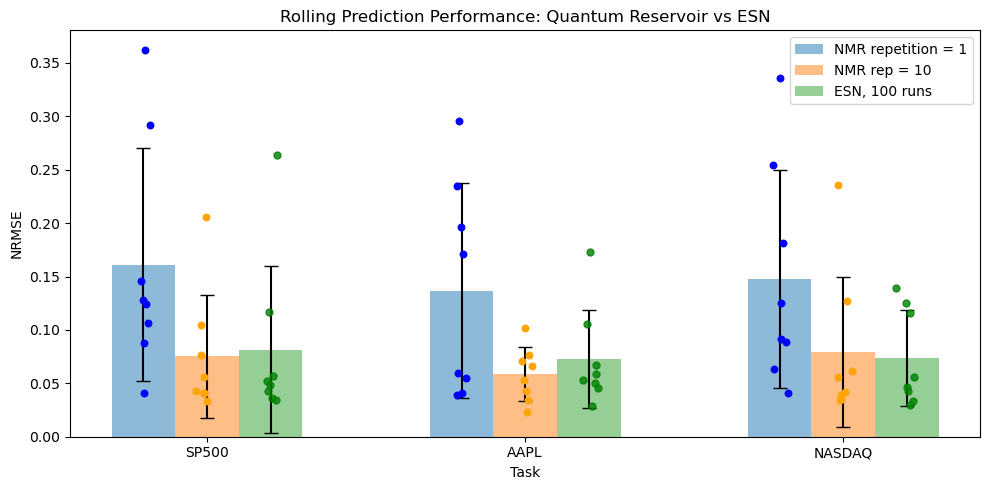

In [35]:
plt.figure(figsize=(10, 5))

width = .2
plt.bar(
    x - width,
    qr_rep1_means,
    width,
    yerr=qr_rep1_stds,
    capsize=5,
    label="NMR repetition = 1",
    alpha=0.5
)

plt.bar(
    x,
    qr_rep10_means,
    width,
    yerr=qr_rep10_stds,
    capsize=5,
    label="NMR repetition = 10",
    alpha=0.5
)

plt.bar(
    x + width,
    esn_means,
    width,
    yerr=esn_stds,
    capsize=5,
    label="ESN, 100 runs",
    alpha=0.5
)

rng = np.random.default_rng(0)

for i, task in enumerate(tasks_name):

    # QR rep = 1 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(qr_rep1_errors[i]))
    plt.scatter(
        np.full(len(qr_rep1_errors[i]), x[i] - width) + jitter,
        qr_rep1_errors[i],
        s=22,
        zorder=3,
        color="blue"
    )

    # QR rep = 10 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(qr_rep10_errors[i]))
    plt.scatter(
        np.full(len(qr_rep10_errors[i]), x[i]) + jitter,
        qr_rep10_errors[i],
        s=22,
        zorder=3,
        color='orange'
    )

    # ESN points: one point per rolling fold, averaged over 100 ESN runs
    esn_points = esn_performance[task]["mean_per_fold"]

    jitter = rng.normal(0, 0.015, size=len(esn_points))
    plt.scatter(
        np.full(len(esn_points), x[i] + width) + jitter,
        esn_points,
        s=25,
        alpha=0.8,
        zorder=3,
        color='green'
    )

plt.xticks(x, tasks_name)
plt.ylabel("NRMSE")
plt.xlabel("Task")
plt.title("Rolling Prediction Performance: Quantum Reservoir vs ESN")
plt.legend()
plt.tight_layout()
plt.show()

We examine multiple ways of node collecting and observe the performance

In [39]:
start = 2014
end = 2024
reps = [1,10]
taus = [5,10,15,20]
performance = {}
for rep in reps:
    for tau in taus:
        csv_name = f'SP500_Features_2014_2024_rep{rep}_tau{tau}.csv'
        ## read pq0
        df = pd.read_csv(csv_name)
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-{tau}",N=tau*2,repeat_steps=rep)
    
        
        results, errors = rollover(start, end, '^GSPC', X_pq, tau=1, Nfading=10)
        performance[csv_name] = errors
    
        print(f'SP500 at rep {rep} and tau {tau} has nrmse: ', errors)
        

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04120042 0.11665127 0.11468563 0.07817026 0.11716624 0.53794036
 0.12567056 0.07589454]
Mean NRMSE: 0.150922409293781
Std NRMSE: 0.15901869269111296
SP500 at rep 1 and tau 5 has nrmse:  [0.04120042 0.11665127 0.11468563 0.07817026 0.11716624 0.53794036
 0.12567056 0.07589454]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04126696 0.12743377 0.12123648 0.08654557 0.13877017 0.34294998
 0.20766123 0.09374571]
Mean NRMSE: 0.14495123546688693
Std NRMSE: 0.0932179930342935
SP500 at rep 1 and tau 10 has nrmse:  [0.04126696 0.12743377 0.12123648 0.08654557 0.13877017 0.34294998
 0.20766123 0.09374571]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...

Final result:
NRMSE values: [0.04062226 0.06099454 0.0550223  0.03148029 0.04055408 0.05892739
 0.05463812 0.03622466]
Mean NRMSE: 0.047307953071794986
Std NRMSE: 0.011334170954338967
SP500 at rep 10 and tau 10 has nrmse:  [0.04062226 0.06099454 0.0550223  0.03148029 0.04055408 0.05892739
 0.05463812 0.03622466]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]
Mean NRMSE: 0.07516599476302113
Std NRMSE: 0.05779956869756436
SP500 at rep 10 and tau 15 has nrmse:  [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04032277 0.11915083 0.06001049 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]
Mean NRMSE: 0.10072222377090298
Std NRMSE: 0.10217778511751946
SP500 at rep 10 and tau 20 has nrmse:  [0.04032277 0.11915083 0.06001049 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]


In [41]:
import numpy as np
import matplotlib.pyplot as plt

reps = [1, 10]
taus = [5, 10, 15, 20]

x = np.arange(len(taus))
width = 0.35

rep1_errors = [
    performance[f"SP500_Features_2014_2024_rep1_tau{tau}.csv"]
    for tau in taus
]

rep10_errors = [
    performance[f"SP500_Features_2014_2024_rep10_tau{tau}.csv"]
    for tau in taus
]

rep1_means = np.array([np.mean(e) for e in rep1_errors])
rep1_stds  = np.array([np.std(e, ddof=1) for e in rep1_errors])

rep10_means = np.array([np.mean(e) for e in rep10_errors])
rep10_stds  = np.array([np.std(e, ddof=1) for e in rep10_errors])

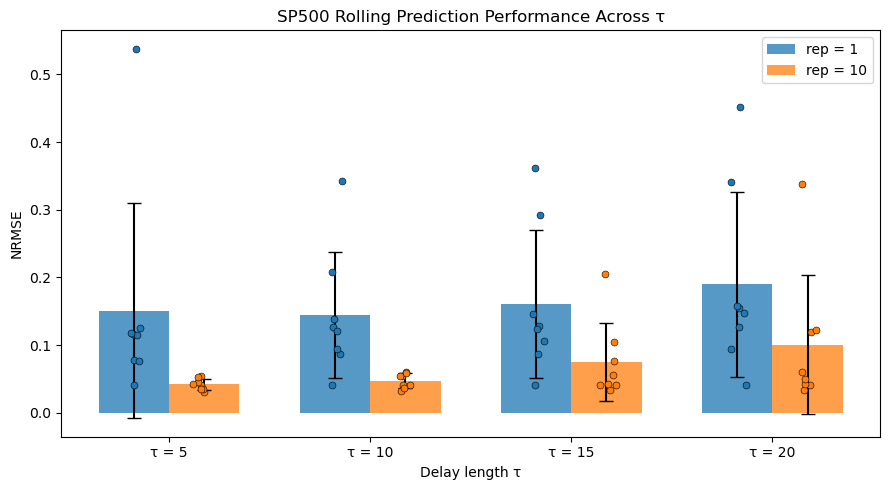

In [43]:
plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    rep1_means,
    width,
    yerr=rep1_stds,
    capsize=5,
    label="repetition = 1",
    color="tab:blue",
    alpha=0.75
)

plt.bar(
    x + width / 2,
    rep10_means,
    width,
    yerr=rep10_stds,
    capsize=5,
    label="repetition = 10",
    color="tab:orange",
    alpha=0.75
)

rng = np.random.default_rng(0)

for i, tau in enumerate(taus):
    jitter = rng.normal(0, 0.025, size=len(rep1_errors[i]))
    plt.scatter(
        np.full(len(rep1_errors[i]), x[i] - width / 2) + jitter,
        rep1_errors[i],
        s=25,
        color="tab:blue",
        edgecolor="black",
        linewidth=0.4,
        zorder=3
    )

    jitter = rng.normal(0, 0.025, size=len(rep10_errors[i]))
    plt.scatter(
        np.full(len(rep10_errors[i]), x[i] + width / 2) + jitter,
        rep10_errors[i],
        s=25,
        color="tab:orange",
        edgecolor="black",
        linewidth=0.4,
        zorder=3
    )

plt.xticks(x, [f"τ = {tau}" for tau in taus])
plt.ylabel("NRMSE")
plt.xlabel("Delay length τ")
plt.title("SP500 Rolling Prediction Performance Across τ")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = 2014
end = 2024

rep = 10  # choose one repeat_steps first
taus = [5, 10, 15, 20]

# number of collected nodes/features
# must be even because each delay gives P and Q
N_values = [2, 4, 6, 8, 10, 20, 30, 40]

performance = {}

for tau in taus:
    csv_name = f"SP500_Features_2014_2024_rep{rep}_tau{tau}.csv"
    df = pd.read_csv(csv_name)

    mean_errors = []
    std_errors = []

    for N in N_values:
        X_pq = extract_delayed_single_column(
            df,
            column_name=f"PQ-{tau}",
            N=N,
            repeat_steps=rep
        )

        results, errors = rollover(
            start,
            end,
            "^GSPC",
            X_pq,
            tau=1,
            Nfading=10
        )
        mean_errors.append(np.mean(errors))
        std_errors.append(np.std(errors))

        print(f"tau={tau}, N={N}, mean NRMSE={np.mean(errors):.4f}, std={np.std(errors):.4f}")

    performance[tau] = {
        "N_values": N_values,
        "mean_errors": mean_errors,
        "std_errors": std_errors
    }

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04125957 0.093006   0.07901776 0.05587201 0.06685613 0.08152438
 0.05997337 0.04346785]
Mean NRMSE: 0.06512213314277182
Std NRMSE: 0.018489544998381457
tau=5, N=2, mean NRMSE=0.0651, std=0.0173


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04086477 0.12216134 0.0581712  0.05307643 0.04569907 0.03514092
 0.05433213 0.03653973]
Mean NRMSE: 0.05574820017422964
Std NRMSE: 0.028137027508746245
tau=5, N=4, mean NRMSE=0.0557, std=0.0263


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...

Final result:
NRMSE values: [0.04042868 0.05255156 0.05219621 0.03330432 0.04165715 0.33445888
 0.1253073  0.05152067]
Mean NRMSE: 0.09142809486526265
Std NRMSE: 0.10233792436442704
tau=20, N=20, mean NRMSE=0.0914, std=0.0957


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04043791 0.10780597 0.05258747 0.03353953 0.042248   0.33838179
 0.12777978 0.05064528]
Mean NRMSE: 0.0991782148191954
Std NRMSE: 0.10256488575454926
tau=20, N=30, mean NRMSE=0.0992, std=0.0959


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04032277 0.11915083 0.06001049 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]
Mean NRMSE: 0.10072222377090298
Std NRMSE: 0.10217778511751946
tau=20, N=40, mean NRMSE=0.1007, std=0.0956


In [61]:
X_pq[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00378732, 0.00655983])

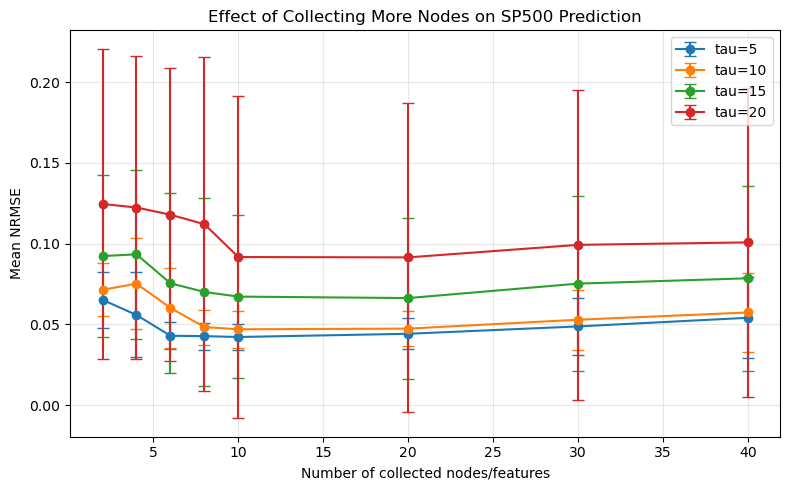

In [63]:
plt.figure(figsize=(8, 5))
taus = [5,10,15,20]
for tau in taus:
    plt.errorbar(
        performance[tau]["N_values"],
        performance[tau]["mean_errors"],
        yerr=performance[tau]["std_errors"],
        marker="o",
        capsize=4,
        label=f"tau={tau}"
    )

plt.xlabel("Number of collected nodes/features")
plt.ylabel("Mean NRMSE")
plt.title("Effect of Collecting More Nodes on SP500 Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()